# **Homework 2 - Image Captioning**

<div style="border: 3px solid #222; padding: 16px; border-radius: 10px; background-color: #1c1f26; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128274;</span>
    <span style="font-size: 16px;"><strong>Project:</strong> Homeworks</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128218;</span>
    <span style="font-size: 16px;"><strong>Course:</strong> Deep Network Development 25/26/2</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #6e8192;">&#128100;</span>
    <span style="font-size: 16px;"><strong>Authors:</strong> Tamás Takács (PhD student, Department of Artificial Intelligence, Eötvös Loránd University) </span>
  </div>
</div>
<hr style="border: none; border-top: 2px solid #444;">
<br>

<img src="https://repository-images.githubusercontent.com/83958320/8f162500-8ace-11e9-94ee-0b86d27bbc5e" alt="1" border="0">

This notebook contains the required task for the **seccond homework** of the **Deep Network Development (DNDEG)** course. Read the task description carefully and **fill in the empty code cells**.

---

## **Task Description**

Train your **own custom image captioning model** and compare its performance with an existing **pre-trained** model using the `MS COCO Captions 2017` dataset.

### Architecture

Your model must follow an **Encoder-Attention-Transformer Decoder** architecture:
- **Encoder:** Pre-trained CNN backbone (e.g., ResNet) that must be **fine-tuned** during training.
- **Decoder:** Transformer-based with multi-head self-attention and cross-attention layers.
- **Controllable Generation:** At least one control mechanism (caption length, style, or focus).
- **Cross-Attention Visualization:** Visualize which image regions the decoder attends to for each generated word.

### Dataset

The **MS COCO Captions 2017** dataset:
- **Training set:** ~118K images with 5 captions each
- **Validation set:** ~5K images with 5 captions each

**Download links:**
- Images (Train): http://images.cocodataset.org/zips/train2017.zip (~18GB)
- Images (Val): http://images.cocodataset.org/zips/val2017.zip (~1GB)
- Annotations: http://images.cocodataset.org/annotations/annotations_trainval2017.zip (~241MB)

Consider limiting the vocabulary to words appearing at least 5 times.

> ⚠️ **Hardware Note:** You may reduce the dataset size (e.g., use a subset of the training images) to fit your current hardware capabilities or cloud resource availability. Ensure you document any such modifications in your notebook.

---

## **Requirements**

**Data Preparation:**
- Download and prepare the MS COCO Captions 2017 dataset
- Display sample images with their original and tokenized captions

**Model Training:**
- Train an Encoder-Attention-Transformer Decoder model
- Track training and validation loss with visualizations
- Monitor BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores
- Implement overfitting prevention (early stopping, regularization, learning rate scheduling)
- Save the best-performing model checkpoint

**Evaluation:**
- Compute BLEU scores using all 5 reference captions per image
- Visualize cross-attention weights showing what the model attends to
- Compare your model with a pre-trained model (e.g., BLIP, ViT-GPT2) on the same validation images
- Provide written analysis of the strengths and weaknesses of both models

> ⚠️ **Performance Note:** Your model is not expected to achieve state-of-the-art results, but it should perform better than random guessing and show decreasing loss during training.

## **Notebook Structure**

The following sections will guide you through the task:

0. Necessary imports
1. Data loading process
2. Defining data augmentations
3. Creating datasets and dataloaders
4. Visualizing training data
5. Creating the image captioning model
6. Defining loss function and optimizer
7. Training the model
8. Evaluation (metrics, cross-attention visualization, inference)
9. Loading a pre-trained model
10. Evaluating the pre-trained model
11. Comparing the two models

The sections are there to guide you but you **do not have to follow them strictly**. Feel free to add more code cells as needed, but keep all code within this notebook (no external `.py` files).

---

## **Submission**

- Upload the final `.ipynb` file to [Canvas](https://canvas.elte.hu) before the deadline (check Canvas for the exact date)
- Copying others' code results in automatic failure
- Please add your **name** and **Neptun ID** in the cell below

---

## **Grading and Feedback**

The submitted notebook is graded as **accepted** or **not accepted**. There is no detailed scoring on the notebook itself. You will receive **written feedback** on your submission within 3 days of the final deadline (earlier if you submit early).

Your grade for this homework is determined at the **oral exam**:
- **15 points**: theoretical questions on your homework (minimum **6/15** required)
- **5 points** if your homework is accepted

Your homework **must be accepted** in order to take the oral exam.

> ⚠️ **Hard requirement:** The assignment will be marked **not accepted** if the training has not been run for **at least 5 epoch**. Ensure your notebook contains evidence of completed training (loss values, saved checkpoints, etc.).

<div style="border: 3px dashed #ff5555; padding: 16px; border-radius: 10px; background-color: #2a1f1f; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="font-size: 18px; font-weight: bold; color: #ff5555; margin-bottom: 12px;">
    ✍️ Fill in your details before submitting
  </div>
</div>



**Name:**  Hayk Grigoryan
**Neptun ID:** XJPYXT

## **0. Necessary Imports**
Import all the necessary packages for this assignment. **ONLY PYTORCH MODELS ARE ACCEPTED!**

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import nltk
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from collections import Counter

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# For COCO dataset loading
# !pip install pycocotools
# from pycocotools.coco import COCO

Using device: cuda:0


## **1. Data Loading Process**

For this assignment you will be using the [MS COCO Captions 2017](https://cocodataset.org/#captions-2017) dataset, which contains **captions/descriptions** of diverse images.

<img src="https://cocodataset.org/images/coco-examples.jpg" alt="COCO Examples" border="0" width="600">

**Download Commands:**

```bash
# Download images
wget http://images.cocodataset.org/zips/train2017.zip        # ~18GB, 118K images
wget http://images.cocodataset.org/zips/val2017.zip          # ~1GB, 5K images

# Download annotations (includes captions)
wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip  # ~241MB
```

After downloading, extract and organize the data:

```
coco/
├── images/
│   ├── train2017/
│   └── val2017/
└── annotations/
    ├── captions_train2017.json
    └── captions_val2017.json
```

You can use the official `pycocotools` library to load and parse the annotations:

```python
!pip install pycocotools
from pycocotools.coco import COCO

coco = COCO('annotations/captions_train2017.json')
```

In [2]:
from pycocotools.coco import COCO

train_ann = os.path.join('annotations', 'captions_train2017.json')
val_ann = os.path.join('annotations', 'captions_val2017.json')

coco_train = COCO(train_ann)
coco_val = COCO(val_ann)

# train_img_ids = list(coco_train.imgs.keys())
# sample_img_id = train_img_ids[0]
# ann_ids = coco_train.getAnnIds(imgIds = sample_img_id)
# annotations = coco_train.loadAnns(ann_ids)

# print(f"\nCaptions for image ID {sample_img_id}:")
# for ann in annotations:
#     print(f"- {ann['caption']}")

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


## **2. Defining Augmentations**

When applying **augmentations** to the `COCO Captions` dataset, it is important to note that these transformations should be applied **only to the images** and not to the captions.

Ensure that your **data augmentation pipeline** includes:
- A **normalization step** to scale pixel values appropriately.
- A **tensor conversion step** to transform images into tensors for model compatibility.
- Additional **augmentations of your choice**, such as random cropping, flipping, or color jittering, to enhance model generalization.

```python
train_transforms = transforms.Compose([
            # Add Augmentations
])

test_transforms = transforms.Compose([
            # Add Augmentations
])
```

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
    ])

## **3. Creating Datasets and Dataloaders**

To load the **COCO Captions** dataset, you need to create a **custom PyTorch** `Dataset` class that returns **images and their corresponding captions**. The captions should be **tokenized** before being returned.

Make sure to include special tokens in your tokenized captions:
- `<sos>` or `<bos>` (Start of Sentence)
- `<eos>` (End of Sentence)
- `<unk>` (Unknown Token) for words outside the vocabulary
- `<pad>` (Padding Token) for batch processing

It is recommended to build a **Vocabulary class** to store all the words in your dataset, as your model can only generate words that exist in this vocabulary. However, saving every word is unnecessary. A **common practice** is to include only words that appear **at least 5 times** across the entire dataset to reduce noise and improve model efficiency.

For the **DataLoader**, ensure that the **batch size** is appropriate so that it fits into memory. Set the **`shuffle`** parameter as follows:

- **Training DataLoader:** `shuffle=True` (to randomize the order of samples)  
- **Validation DataLoader:** `shuffle=False` (to maintain consistency in evaluation)

> **Note**: Remember that batches contain examples with **different caption lengths**. Use a custom `collate_fn` to handle padding and create attention masks for the Transformer decoder.

```python
class Vocabulary:
    """Vocabulary class to map words to indices."""
    def __init__(self, freq_threshold=5):
        raise NotImplementedError

    def build_vocabulary(self, captions):
        raise NotImplementedError

    def numericalize(self, text):
        # Returns: list of token indices
        raise NotImplementedError


class COCOCaptionsDataset(Dataset):
    def __init__(self, root, annFile, vocab, transform=None):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __getitem__(self, idx):
        # Returns: image, caption_tokens, caption_length
        raise NotImplementedError


def collate_fn(batch):
    # Returns: images, padded_captions, lengths, attention_masks
    raise NotImplementedError
```

In [5]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hayk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
from torch.nn.utils.rnn import pad_sequence

class Vocabulary():
    def __init__(self, freq_threshold=5):
        """Vocabulary class to map words to indices."""
        self.SOS_token = '<sos>'
        self.EOS_token = '<eos>'
        self.UNK_token = '<unk>'
        self.PAD_token = '<pad>'
        self.min_fq = freq_threshold

        self.SHORT_token = '<short>'
        self.MEDIUM_token = '<medium>'
        self.LONG_token = '<long>'

        self.PAD_idx = 0
        self.SOS_idx = 1
        self.EOS_idx = 2
        self.UNK_idx = 3
        self.SHORT_idx = 4
        self.MEDIUM_idx = 5
        self.LONG_idx = 6

        self.index2word = {
            self.SOS_idx: self.SOS_token,
            self.EOS_idx: self.EOS_token,
            self.UNK_idx: self.UNK_token,
            self.PAD_idx: self.PAD_token,
            self.SHORT_idx: self.SHORT_token,
            self.MEDIUM_idx: self.MEDIUM_token,
            self.LONG_idx: self.LONG_token
        }
        self.word2index = {word: idx for idx, word in self.index2word.items()}
    
    def build_vocabulary(self, captions):
        all_words = []
        for sentence in captions:
            tokens = nltk.tokenize.word_tokenize(sentence.lower())
            all_words.extend(tokens)

        count_captions = Counter(all_words)
        for word,count in count_captions.items():
            if count >= self.min_fq:
                if word not in self.word2index:
                    idx = len(self.index2word)
                    self.word2index[word] = idx
                    self.index2word[idx] = word

    def numericalize(self, text):
        # Returns: list of token indices
        tokenized = nltk.tokenize.word_tokenize(text.lower())
        tokenized = [self.word2index.get(token, self.UNK_idx) for token in tokenized]
        return [self.SOS_idx] + tokenized + [self.EOS_idx]



class COCOCaptionsDataset(Dataset):
    def __init__(self, root, annFile, vocab, transform=None, dataset_limit=None):
        self.root = root
        self.vocab = vocab
        self.transform = transform

        self.coco = COCO(annFile)
        self.ids = list(self.coco.imgs.keys())
        if dataset_limit is not None:
            import random
            random.seed(42)
            self.ids = random.sample(self.ids, dataset_limit)

    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])

        image = Image.open(img_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)
        
        ann_ids = self.coco.getAnnIds(imgIds = img_id)
        anns = self.coco.loadAnns(ann_ids)

        caption_text = anns[0]['caption']
        caption_tokens = self.vocab.numericalize(caption_text)
        caption_tensor = torch.tensor(caption_tokens, dtype=torch.long)
        caption_length = len(caption_tensor)
        
        if caption_length < 8:
            control_token = '<short>'
        elif caption_length < 13:
            control_token = '<medium>'
        else:
            control_token = '<long>'
            
        control_idx = self.vocab.word2index[control_token] 
        return image, caption_tensor, control_idx, caption_length


def collate_fn(batch):
    """Returns: images, padded_captions, lengths, attention_masks"""
    batch.sort(key = lambda x: x[3], reverse = True) 
    images = [item[0] for item in batch]
    captions = [item[1] for item in batch]
    control_idxs = [item[2] for item in batch] # New!
    lengths = [item[3] for item in batch]

    images = torch.stack(images, dim = 0)
    padded = pad_sequence(captions, batch_first = True, padding_value = 0)
    attention_masks = (padded != 0)
    
    control_idxs = torch.tensor(control_idxs, dtype=torch.long)
    lengths = torch.tensor(lengths, dtype=torch.long)

    return images, padded, control_idxs, lengths, attention_masks



vocab = Vocabulary()
captions = []
ann_ids = coco_train.getAnnIds()
anns = coco_train.loadAnns(ann_ids)
for ann in anns:
    captions.append(ann['caption'])
vocab.build_vocabulary(captions)

train_img_dir = os.path.join('images', 'train2017')
val_img_dir = os.path.join('images', 'val2017')

train_dataset = COCOCaptionsDataset(root = train_img_dir, annFile = train_ann, vocab = vocab, transform = train_transforms, dataset_limit = 40000)
val_dataset = COCOCaptionsDataset(root = val_img_dir, annFile = val_ann, vocab = vocab, transform = test_transforms, dataset_limit = 5000)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, collate_fn = collate_fn)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False, collate_fn = collate_fn)



loading annotations into memory...
Done (t=0.55s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


## **4. Visualizing Training Data**

To visualize the training data, extract a batch from the training `DataLoader` and plot the **input-target** pairs using `Matplotlib` or `Seaborn`. Ensure that at least **8 pairs** are displayed for a clear representation.

Make sure to **visualize the original and the tokenized caption** as well!

```python
def visualize_batch(dataloader, vocab, num_samples=8):
    raise NotImplementedError
```

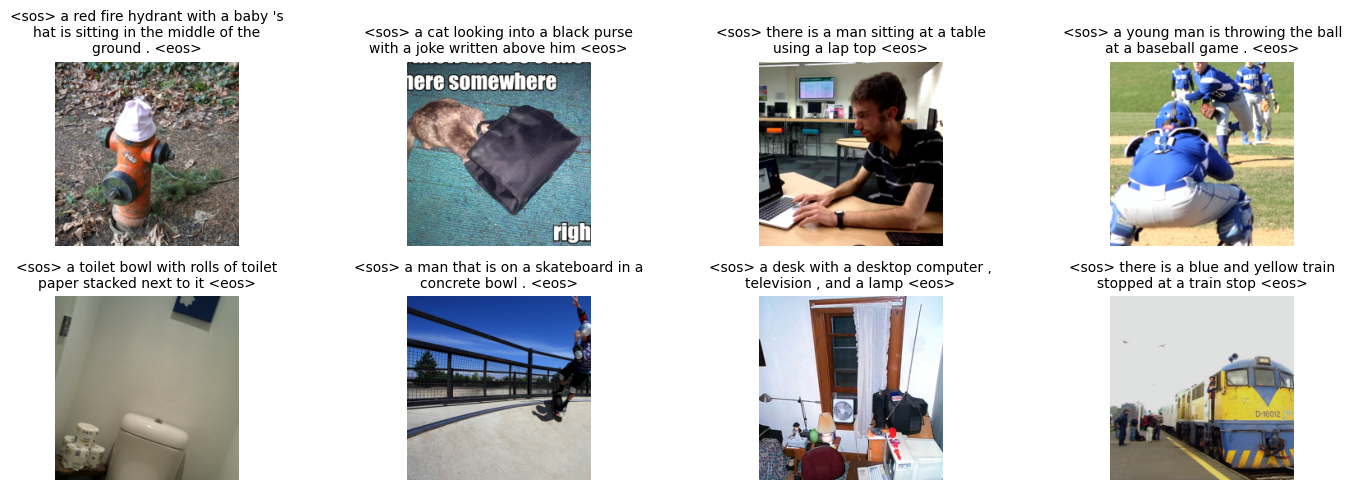

In [7]:
import textwrap

def visualize_batch(dataloader, captions, vocab, num_samples = 8):
    batch = next(iter(dataloader))
    images, captions, control_idxs, lengths, masks = batch
    batch_size = images.size(0)
    num_samples = min(num_samples, batch_size)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        caption_indices = captions[i].cpu().numpy()
        caption_words = [vocab.index2word.get(idx, '<unk>') for idx in caption_indices if idx not in [vocab.PAD_idx]]
        caption_text = ' '.join(caption_words)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        wrapped_caption = textwrap.fill(caption_text, width=40)
        plt.title(wrapped_caption, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_batch(train_loader, captions, vocab)

## **5. Creating the Image Captioning Model**

For this assignment, **you are required to create your own custom image captioning model** and **compare its performance** with an existing pre-trained model.

---

### **Encoder-Attention-Transformer Decoder Architecture**

Your model must follow an **Encoder-Attention-Transformer Decoder** architecture:

#### **1. Encoder (CNN-based)**
The encoder processes images to extract spatial features:
- Use a **pre-trained CNN** (e.g., ResNet-50, ResNet-101) as the backbone.
- Remove the final classification layers to obtain feature maps.
- **Fine-tuning is required** - at minimum, fine-tune the last few layers.
- Output shape should be `(batch_size, num_patches, encoder_dim)` where patches come from spatial locations in the feature map.

#### **2. Transformer Decoder**
The decoder must be **Transformer-based** with the following components:
- **Positional Encoding** for caption token positions.
- **Masked Multi-Head Self-Attention** to prevent attending to future tokens.
- **Cross-Attention** layers to attend to encoder features (image patches).
- **Feed-Forward Networks** with residual connections and layer normalization.

> **Note:** An LSTM/GRU decoder is **not acceptable** for this assignment. You must implement a Transformer decoder.

#### **3. Controllable Generation**
Implement at least one form of caption control:
- **Length Control:** Condition the decoder on desired caption length (short/medium/long).
- **Style Control:** Add style embeddings (formal/casual/descriptive).
- **Focus Control:** Emphasize specific detected objects or regions.

This can be done by adding **control embeddings** to the decoder input or using **special control tokens**.

---

### **Code Skeleton**

```python
class CNNEncoder(nn.Module):
    """CNN-based image encoder using pre-trained backbone."""
    def __init__(self, encoder_dim=2048, fine_tune_from=6):
        super(CNNEncoder, self).__init__()
        # Load pre-trained ResNet, remove final layers
        # Enable fine-tuning for layers >= fine_tune_from
        raise NotImplementedError

    def forward(self, images):
        # Returns: (batch_size, num_patches, encoder_dim)
        raise NotImplementedError
```

```python
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        raise NotImplementedError

    def forward(self, x):
        raise NotImplementedError
```

```python
class TransformerDecoderLayer(nn.Module):
    """Single Transformer decoder layer with masked self-attention and cross-attention."""
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super(TransformerDecoderLayer, self).__init__()
        # Masked multi-head self-attention
        # Cross-attention to encoder features
        # Feed-forward network
        raise NotImplementedError

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # Returns: output, cross_attention_weights (for visualization)
        raise NotImplementedError
```

```python
class TransformerDecoder(nn.Module):
    """Full Transformer decoder with embedding and output projection."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, dim_feedforward, dropout=0.1):
        super(TransformerDecoder, self).__init__()
        # Word embedding + positional encoding
        # Control embedding (for controllable generation)
        # Stack of TransformerDecoderLayer
        # Output projection to vocab
        raise NotImplementedError

    def forward(self, captions, encoder_features, tgt_mask=None, control_signal=None):
        # control_signal: optional (e.g., desired length, style)
        # Returns: logits, list of cross_attention_weights from each layer
        raise NotImplementedError

    def generate_square_subsequent_mask(self, sz):
        """Generate causal mask for autoregressive decoding."""
        raise NotImplementedError
```

```python
class ImageCaptioningModel(nn.Module):
    """Full image captioning model: Encoder + Transformer Decoder."""
    def __init__(self, vocab_size, encoder_dim, d_model, num_heads, num_layers, dim_feedforward):
        super(ImageCaptioningModel, self).__init__()
        raise NotImplementedError

    def forward(self, images, captions, control_signal=None):
        # Returns: logits, cross_attention_weights
        raise NotImplementedError

    def generate(self, images, max_len=50, control_signal=None):
        """Autoregressive caption generation (greedy or beam search)."""
        raise NotImplementedError
```

In [8]:
import torchvision.models as models
import math

class CNNEncoder(nn.Module):
    """CNN-based image encoder using pre-trained backbone."""
    def __init__(self, encoder_dim=2048, fine_tune_from=6):
        super(CNNEncoder, self).__init__()
        # Load pre-trained ResNet, remove final layers
        # Enable fine-tuning for layers >= fine_tune_from
        resnet = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        for i, child in enumerate(self.resnet.children()):
            if i < fine_tune_from:
                for param in child.parameters():
                    param.requires_grad = False
            else:
                for param in child.parameters():
                    param.requires_grad = True

    def forward(self, images):
        # Returns: (batch_size, num_patches, encoder_dim)
        features = self.resnet(images)
        features = features.permute(0,2,3,1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super(PositionalEncoding, self).__init__()

        self.dropout = nn.Dropout(p = dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[: ,1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerDecoderLayer(nn.Module):
    """Single Transformer decoder layer with masked self-attention and cross-attention."""
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super(TransformerDecoderLayer, self).__init__()
        # Masked multi-head self-attention
        # Cross-attention to encoder features
        # Feed-forward network
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, batch_first = True, dropout = dropout)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, batch_first = True, dropout = dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # Returns: output, cross_attention_weights (for visualization)
        attn_output, attn_weights = self.self_attn(query = tgt, key = tgt, value = tgt, attn_mask = tgt_mask, key_padding_mask = tgt_key_padding_mask)
        tgt = self.norm1(tgt + self.dropout1(attn_output))
        attn_output, cross_attention_weights = self.cross_attn(query = tgt, key = memory, value = memory, need_weights = True, average_attn_weights = True)
        tgt = self.norm2(tgt + self.dropout2(attn_output))
        ff_output = self.linear2(self.dropout(F.relu(self.linear1(tgt))))
        tgt = self.norm3(tgt + self.dropout3(ff_output))
        return tgt, cross_attention_weights
    
class TransformerDecoder(nn.Module):
    """Full Transformer decoder with embedding and output projection."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, dim_feedforward, dropout=0.1):
        super(TransformerDecoder, self).__init__()
        # Word embedding + positional encoding
        # Control embedding (for controllable generation)
        # Stack of TransformerDecoderLayer
        # Output projection to vocab
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout = dropout)
        self.control_embedding = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([TransformerDecoderLayer(d_model, num_heads, dim_feedforward, dropout) for i in range(num_layers)])
        self.output_projection = nn.Linear(d_model, vocab_size)

    def forward(self, captions, encoder_features, tgt_mask=None, control_signal=None):
        # control_signal: optional (e.g., desired length, style)
        # Returns: logits, list of cross_attention_weights from each layer
        x = self.embedding(captions) * math.sqrt(self.embedding.embedding_dim)
        if control_signal is not None:
            control_emb = self.control_embedding(control_signal).unsqueeze(1)
            control_emb = control_emb * math.sqrt(self.embedding.embedding_dim) 
            x = x + control_emb
        
        x = self.positional_encoding(x)
        all_attention_weights = []
        pad_mask = (captions == 0)
        for layer in self.layers:
            x, attn_weights = layer(tgt = x, memory = encoder_features, tgt_mask = tgt_mask, tgt_key_padding_mask = pad_mask)
            all_attention_weights.append(attn_weights)
        logits = self.output_projection(x)
        return logits, all_attention_weights

    def generate_square_subsequent_mask(self, sz):
        """Generate causal mask for autoregressive decoding."""
        mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool()
        return mask

class ImageCaptioningModel(nn.Module):
    """Full image captioning model: Encoder + Transformer Decoder."""
    def __init__(self, vocab_size, encoder_dim, d_model, num_heads, num_layers, dim_feedforward):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = CNNEncoder(encoder_dim = encoder_dim)
        self.feature_projection = nn.Linear(encoder_dim, d_model)
        self.decoder = TransformerDecoder(vocab_size = vocab_size, d_model = d_model, 
                                          num_heads = num_heads, num_layers = num_layers, 
                                          dim_feedforward = dim_feedforward)
        

    def forward(self, images, captions, control_signal=None):
        # Returns: logits, cross_attention_weights
        encoder_features = self.encoder(images)
        encoder_features = self.feature_projection(encoder_features)
        tgt_seq_len = captions.size(1)
        tgt_mask = self.decoder.generate_square_subsequent_mask(tgt_seq_len).to(images.device)
        logits, cross_attention_weights = self.decoder(captions= captions, encoder_features = encoder_features, 
                                                       tgt_mask = tgt_mask, control_signal = control_signal)
        return logits, cross_attention_weights
    
    def generate(self, images, max_len=50, control_signal=None):
        """Autoregressive caption generation (greedy or beam search)."""
        self.eval()

        with torch.no_grad():
            encoder_features = self.encoder(images)
            encoder_features = self.feature_projection(encoder_features)

            batch_size = images.size(0)
            generated_captions = torch.full((batch_size, 1), vocab.SOS_idx, dtype=torch.long, device = images.device)
            all_attention_weights = []

            for i in range(max_len):
                tgt_mask = self.decoder.generate_square_subsequent_mask(generated_captions.size(1)).to(images.device)
                logits, attention_weights = self.decoder(captions=generated_captions, encoder_features=encoder_features, tgt_mask=tgt_mask, control_signal=control_signal)
                next_token_logits = logits[:, -1, :]
                next_tokens = next_token_logits.argmax(dim=-1).unsqueeze(1)
                generated_captions = torch.cat((generated_captions, next_tokens), dim=1)
                all_attention_weights.append(attention_weights)
                if (generated_captions == vocab.EOS_idx).all():
                    break
        
        self.train()
        return generated_captions, all_attention_weights
    

vocab_size = len(vocab.index2word)
encoder_dim = 2048
d_model = 512
num_heads = 8
num_layers = 3
dim_feedforward = 2048
model = ImageCaptioningModel(vocab_size, encoder_dim, d_model, num_heads, num_layers, dim_feedforward).to(device)

## **6. Defining Loss Function and Optimizer**

### **Loss Function**

For image captioning, we use **Cross-Entropy Loss** - the standard loss for sequence prediction tasks. It measures the difference between the predicted word probability distribution and the true word at each time step:

$$
\mathcal{L}_{CE} = -\sum_{t=1}^{T} \log P(y_t | y_{1:t-1}, X)
$$

where $T$ is the caption length and $y_t$ is the ground truth word at position $t$.

**Implementation notes:**
- Use `nn.CrossEntropyLoss(ignore_index=pad_idx)` to ignore padding tokens in the loss calculation
- During training, use **teacher forcing**: feed the ground truth tokens as input to predict the next token

```python
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])
```

---

### **Optimizer**

Common choices for training Transformers:

- **Adam/AdamW** - Recommended for most cases. AdamW adds proper weight decay.
- **SGD with momentum** - Can work but typically requires more tuning.

```python
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
```

Consider using a **learning rate scheduler** (e.g., `torch.optim.lr_scheduler.ReduceLROnPlateau`) to reduce the learning rate when validation loss plateaus.

**References:**
- [PyTorch Loss Functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
- [PyTorch Optimizers](https://pytorch.org/docs/stable/optim.html)

In [9]:
criterion = nn.CrossEntropyLoss(ignore_index = vocab.PAD_idx)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## **7. Training the Image Captioning Model**

Implement a training loop with the following features:

- Track **training loss** and **validation loss** per epoch
- Implement **early stopping** when validation loss stops improving
- **Save the best model** checkpoint based on validation loss
- Store losses for later visualization

```python
def train_epoch(model, dataloader, criterion, optimizer, device):
    # Returns: average training loss
    raise NotImplementedError


def validate(model, dataloader, criterion, device):
    # Returns: average validation loss
    raise NotImplementedError


def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    # Returns: train_losses, val_losses
    raise NotImplementedError
```

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, epoch, device):
    # Returns: average training loss
    model.train()
    total_loss = 0
    for i, batch in enumerate(dataloader):
        images, captions, control_idxs, lengths, masks = batch
        images = images.to(device)
        captions = captions.to(device)
        control_idxs = control_idxs.to(device)
        inputs = captions[:,:-1]
        targets = captions[:, 1:]
        optimizer.zero_grad()
        logits, _ = model(images, inputs, control_signal=control_idxs)
        logits = logits.reshape(-1, logits.size(-1))
        targets = targets.reshape(-1)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        if (i + 1) % 50 == 0:
            print(f"Epoch {epoch}, Batch {i+1}/{len(dataloader)}, Loss: {total_loss / (i+1):.4f}")
        
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    # Returns: average validation loss
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            images, captions, control_idxs, lengths, masks = batch
            images = images.to(device)
            captions = captions.to(device)
            control_idxs = control_idxs.to(device)
            inputs = captions[:,:-1]
            targets = captions[:, 1:]
            logits, _ = model(images, inputs, control_signal=control_idxs)
            logits = logits.reshape(-1, logits.size(-1))
            targets = targets.reshape(-1)
            loss = criterion(logits, targets)
            total_loss += loss.item()
    return total_loss / len(dataloader)


def train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, patience=5):
    #  Returns: train_losses, val_losses
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    trigger_times = 0
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
        train_loss = train_epoch(model, train_loader, criterion, optimizer, epoch, device)
        train_losses.append(train_loss)
        val_loss = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        print(f"Epoch {epoch} completed. Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_image_captioning_model.pth')
            print("Model saved.")
        else:
            trigger_times += 1
            print(f"Validation loss did not improve. Trigger times: {trigger_times}/{patience}")
            if trigger_times >= patience:
                print("Early stopping triggered.")
                break
    return train_losses, val_losses



train_losses, val_losses = train(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    scheduler=scheduler,
    num_epochs=10, 
    device=device
)


--- Epoch 1/10 ---
Epoch 0, Batch 50/1250, Loss: 5.3667
Epoch 0, Batch 100/1250, Loss: 4.9122
Epoch 0, Batch 150/1250, Loss: 4.6903
Epoch 0, Batch 200/1250, Loss: 4.5194
Epoch 0, Batch 250/1250, Loss: 4.4102
Epoch 0, Batch 300/1250, Loss: 4.3371
Epoch 0, Batch 350/1250, Loss: 4.2617
Epoch 0, Batch 400/1250, Loss: 4.2062
Epoch 0, Batch 450/1250, Loss: 4.1597
Epoch 0, Batch 500/1250, Loss: 4.1188
Epoch 0, Batch 550/1250, Loss: 4.0802
Epoch 0, Batch 600/1250, Loss: 4.0483
Epoch 0, Batch 650/1250, Loss: 4.0205
Epoch 0, Batch 700/1250, Loss: 3.9993
Epoch 0, Batch 750/1250, Loss: 3.9750
Epoch 0, Batch 800/1250, Loss: 3.9525
Epoch 0, Batch 850/1250, Loss: 3.9328
Epoch 0, Batch 900/1250, Loss: 3.9146
Epoch 0, Batch 950/1250, Loss: 3.8961
Epoch 0, Batch 1000/1250, Loss: 3.8791
Epoch 0, Batch 1050/1250, Loss: 3.8651
Epoch 0, Batch 1100/1250, Loss: 3.8518
Epoch 0, Batch 1150/1250, Loss: 3.8368
Epoch 0, Batch 1200/1250, Loss: 3.8236
Epoch 0, Batch 1250/1250, Loss: 3.8154
Epoch 0 completed. Train 

## **8.1 Visualizing Training Metrics**

- **Restore the model's parameters** from the checkpoint where validation loss was lowest to use the most optimal version of the model.
- Use `Matplotlib` or `Seaborn` to plot the loss curves over epochs.

Did your model **converge**? Explain your results!

```python
def plot_losses(train_losses, val_losses):
    raise NotImplementedError
```

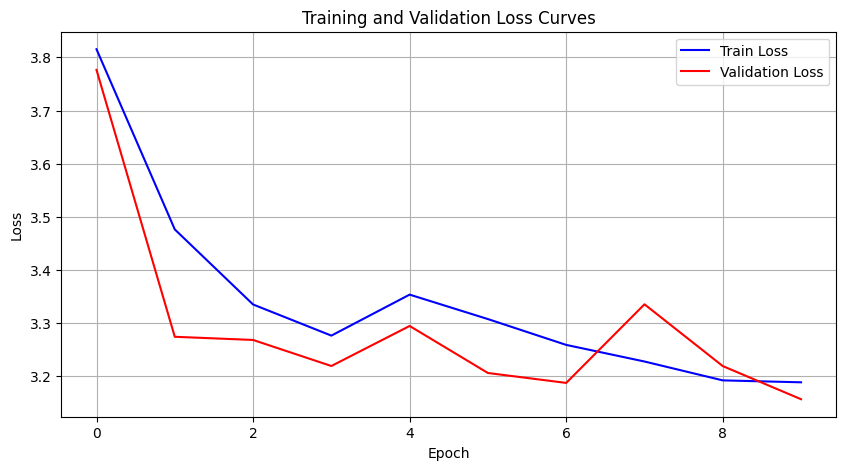

In [11]:
def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label='Train Loss', color = 'blue')
    plt.plot(val_losses, label='Validation Loss', color = 'red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid()
    plt.show()

plot_losses(train_losses, val_losses)

## **8.2 Visualizing Cross-Attention Weights**

Visualize the **cross-attention weights** from your Transformer decoder to understand what image regions the model focuses on when generating each word.

For each generated word, the cross-attention layer produces weights over the image patches. By reshaping these weights back to the spatial dimensions and overlaying them on the original image, you can create interpretable **attention heatmaps**.

- Show attention maps for at least **5 different images** from the validation set
- For each image, display the attention heatmap for **each word** in the generated caption
- Optionally, average attention across decoder layers or heads for clearer visualization

```python
def visualize_cross_attention(image, caption_tokens, attention_weights):
    raise NotImplementedError
```

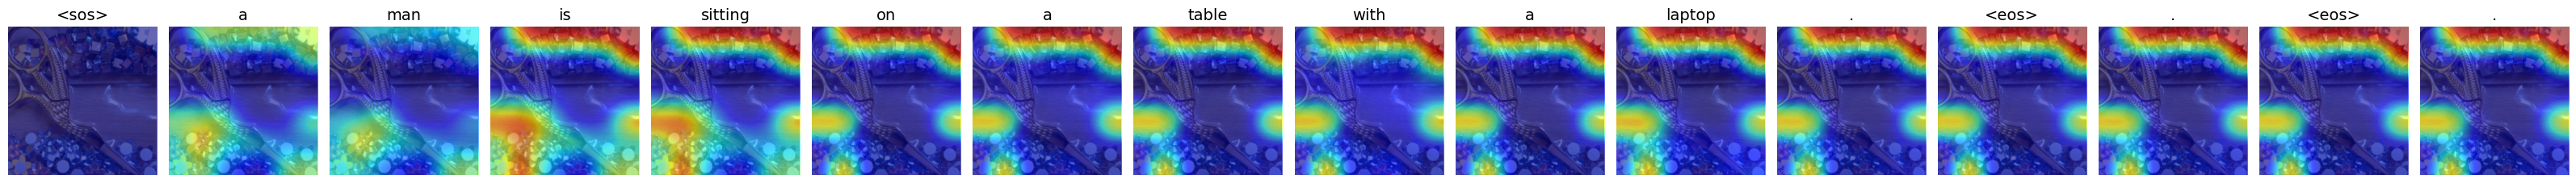

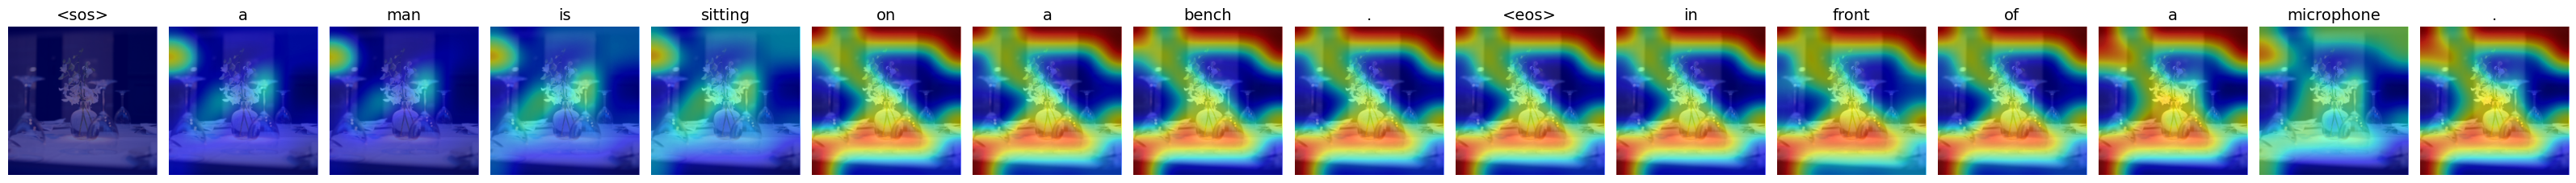

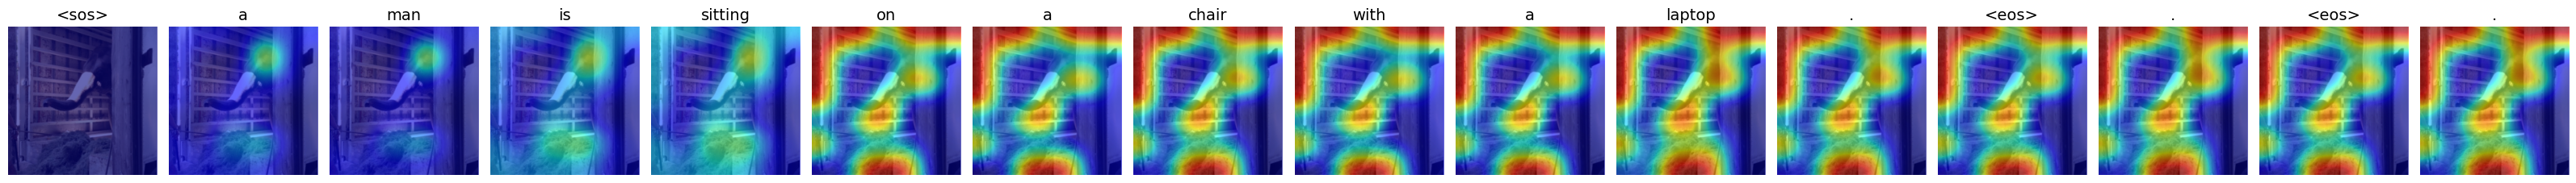

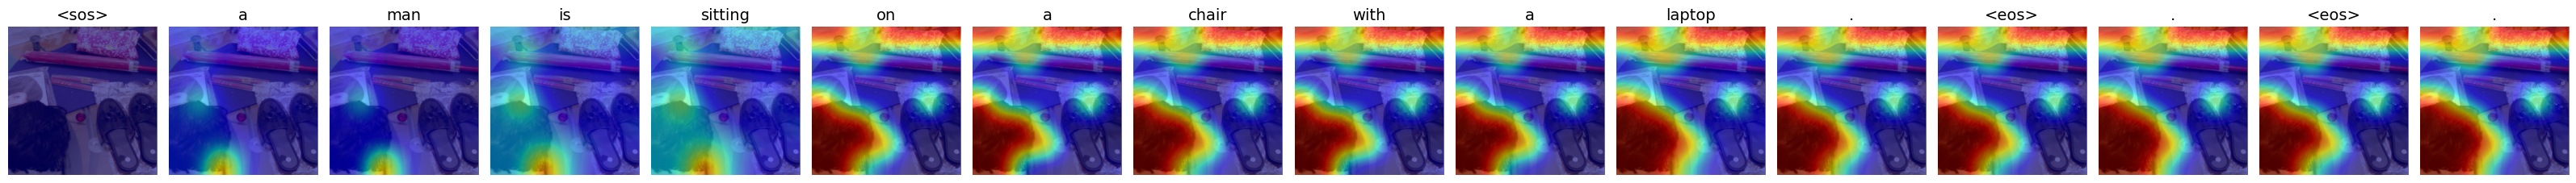

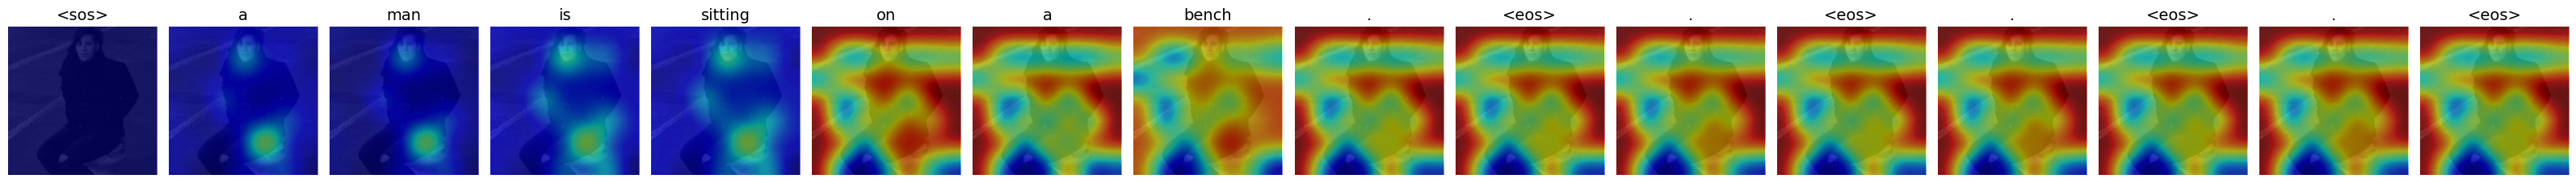

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

def visualize_cross_attention(image, caption_tokens, attention_weights):
    if isinstance(image, torch.Tensor):
        img = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
    else:
        img = image
    num_words = len(caption_tokens)
    
    fig = plt.figure(figsize=(2 * num_words, 4))
    
    for j in range(num_words):
        word = caption_tokens[j]
        attn = attention_weights[j]
        
        if isinstance(attn, torch.Tensor):
            attn = attn.cpu().detach().numpy()
            
        attn_map = attn.reshape(7, 7)
        
        plt.subplot(1, num_words, j + 1)
        plt.imshow(img)
        plt.imshow(attn_map, alpha=0.6, cmap='jet', extent=(0, 224, 224, 0), interpolation='bicubic')
        plt.axis('off')
        plt.title(word, fontsize=14)
        
    plt.tight_layout()
    plt.show() 
    plt.close(fig)

model.eval()

batch = next(iter(val_loader))
images, captions, control_idxs, lengths, masks = batch
images = images.to(device)
control_idxs = control_idxs.to(device)

with torch.no_grad():
    generated_ids, all_attention_weights = model.generate(images, max_len=15, control_signal=control_idxs)

for i in range(5):
    seq_idxs = generated_ids[i].cpu().numpy()
    words = [vocab.index2word.get(idx, '<unk>') for idx in seq_idxs if idx != vocab.PAD_idx]
    
    img_attn_weights = []
    
    for step in range(len(words) - 1): 
        try:
            attn = all_attention_weights[step][-1][i, -1, :]
            img_attn_weights.append(attn)
        except Exception as e:
            print(f"Warning: Math mismatch on step {step}. Skipping heatmap.")
            
    blank_attn = torch.zeros(49)
    img_attn_weights = [blank_attn] + img_attn_weights

    visualize_cross_attention(images[i], words, img_attn_weights)

## **8.3 Running Inference on the Image Captioning Model**

Pass validation images through the **custom-trained image captioning model** and evaluate its performance. Use the **BLEU score** as the evaluation metric, computing **BLEU-1, BLEU-2, BLEU-3, and BLEU-4**.

**Evaluation Requirements:**
- Compute BLEU scores using **all 5 reference captions** for each image
- Report average BLEU scores across the entire validation set
- Show generated captions for at least 10 sample images alongside ground-truth captions

**Decoding Options:**
- **Greedy decoding** (required): Select the most probable word at each step
- **Beam search** (extra credit): Maintain top-k candidate sequences

**Also demonstrate your controllable generation:**
- Show how different control signals (length/style/focus) affect the generated captions for the same image

```python
def generate_caption(model, image, vocab, max_len=50, control_signal=None):
    # Returns: caption string, attention_weights
    raise NotImplementedError


def evaluate_model(model, dataloader, vocab):
    # Returns: dict with BLEU-1, BLEU-2, BLEU-3, BLEU-4
    raise NotImplementedError
```

In [13]:
from nltk.translate.bleu_score import corpus_bleu

def generate_caption(model, image, vocab, max_len=50, control_signal=None):
    if image.dim() == 3:
        image = image.unsqueeze(0)
    
    generated_ids, all_attention_weights = model.generate(image, max_len=max_len, control_signal=control_signal)
    seq_idxs = generated_ids[0].cpu().numpy()
    
    words = []
    for idx in seq_idxs:
        if idx == vocab.EOS_idx:
            break
        if idx not in [vocab.PAD_idx, vocab.SOS_idx]:
            word = vocab.index2word.get(idx, '<unk>')
            if words and word == words[-1]:
                continue
            words.append(word)
            
    final_caption = " ".join(words).split(' .')[0]
    return final_caption, all_attention_weights


def evaluate_model(model, dataloader, vocab):
    references = []
    hypotheses = []
    
    dataset = dataloader.dataset
    coco = dataset.coco
    device = next(model.parameters()).device
    
    idx = 0
    for batch in dataloader:
        images, captions, control_idxs, lengths, masks = batch
        images = images.to(device)
        batch_size = images.size(0)
        default_signals = torch.full((batch_size,), vocab.MEDIUM_idx, dtype=torch.long).to(device)
        generated_ids, _ = model.generate(images, max_len=20, control_signal=default_signals)
        
        for j in range(images.size(0)):
            hyp_idxs = generated_ids[j].cpu().numpy()
            
            hyp_words = []
            for i in hyp_idxs:
                if i == vocab.EOS_idx:
                    break
                if i not in [vocab.PAD_idx, vocab.SOS_idx]:
                    word = vocab.index2word.get(i, '<unk>')
                    if hyp_words and word == hyp_words[-1]:
                        continue
                    hyp_words.append(word)
                    
            hypotheses.append(hyp_words)
            
            img_id = dataset.ids[idx]
            ann_ids = coco.getAnnIds(imgIds=img_id)
            anns = coco.loadAnns(ann_ids)
            
            img_refs = []
            for ann in anns:
                ref_tokens = nltk.tokenize.word_tokenize(ann['caption'].lower())
                img_refs.append(ref_tokens)
            references.append(img_refs)
            
            idx += 1
            
    bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
    
    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4
    }

## **9. Loading an Existing Image Captioning Model**

Load a pre-trained image captioning model for comparison. Recommended options:

- **BLIP:** Available on [Hugging Face](https://huggingface.co/Salesforce/blip-image-captioning-base)
- **ViT-GPT2:** Available on [Hugging Face](https://huggingface.co/nlpconnect/vit-gpt2-image-captioning)

```python
def load_pretrained_model():
    # Returns: model, processor/tokenizer
    raise NotImplementedError
```

In [14]:
from transformers import BlipProcessor, BlipForConditionalGeneration

def load_pretrained_model():
    processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
    return blip_model, processor

## **10. Evaluating the Existing Image Captioning Model**

Apply the **same metrics** used for your custom model to ensure a fair comparison.

```python
def evaluate_pretrained_model(model, processor, dataloader):
    # Returns: dict with BLEU-1, BLEU-2, BLEU-3, BLEU-4
    raise NotImplementedError
```

In [15]:
def evaluate_pretrained_model(model, processor, dataloader):
    model.eval()
    references = []
    hypotheses = []
    
    dataset = dataloader.dataset
    coco = dataset.coco
    device = next(model.parameters()).device
    
    with torch.no_grad():
        idx = 0
        for i, batch in enumerate(dataloader):
            images, captions, control_idxs, lengths, masks = batch
            
            for j in range(images.size(0)):
                img_id = dataset.ids[idx]
                img_info = coco.loadImgs(img_id)[0]
                img_path = os.path.join(dataset.root, img_info['file_name'])
                raw_image = Image.open(img_path).convert('RGB')
                
                inputs = processor(images=raw_image, return_tensors="pt").to(device)
                generated_ids = model.generate(**inputs, max_length=20)
                generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
                hypotheses.append(generated_text.split())
                
                ann_ids = coco.getAnnIds(imgIds=img_id)
                anns = coco.loadAnns(ann_ids)
                img_refs = []
                for ann in anns:
                    ref_tokens = nltk.tokenize.word_tokenize(ann['caption'].lower())
                    img_refs.append(ref_tokens)
                references.append(img_refs)
                
                idx += 1
            
            if i >= 4:
                break
                
    bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
    
    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4
    }

## **11. Comparing the Two Models**

Compare the performance of both models using **BLEU-1, BLEU-2, BLEU-3, and BLEU-4** scores. Visualize predictions from both models on the **same validation images**.

**Requirements:**
- Create a comparison table with BLEU scores for both models
- Show side-by-side caption comparisons for at least 10 images
- Compare attention/focus patterns if the pre-trained model provides attention weights

```python
def compare_models(custom_results, pretrained_results):
    # Display comparison table and visualizations
    raise NotImplementedError
```

**Analysis (Written Response Required):**
1. Why does the pre-trained model perform better/worse on certain images?
2. What architectural differences contribute to performance gaps?
3. How does your Transformer decoder compare to the decoder used in the pre-trained model?
4. Propose **at least 3 specific improvements** for your custom model based on this analysis.

> **Answer**: 
1. Blip performs better because it was trained on a much bigger dataset and had more computational power, while my model is constrainted to only 10000 samples and 5 epochs
2. Blip uses ViT, while my model uses ResNet-50 CNN which worse for spatial awareness, also Blip uses another loss before training which better aligns the visual and text embeddings
3. My custom decoder uses standard sinusoidal positional encodings and a basic 3-layer stack, Blip uses a much deeper multimodal text decoder based on the BERT which by far more complex
4. a) Scale the Training
4. b)Implement Beam Search Decoding
4. c)Switch to a ViT Backbone

In [16]:
import pandas as pd

def compare_models(custom_results, pretrained_results):
    df = pd.DataFrame({
        "Metric": ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"],
        "Custom Model": [custom_results["BLEU-1"], custom_results["BLEU-2"], custom_results["BLEU-3"], custom_results["BLEU-4"]],
        "BLIP": [pretrained_results["BLEU-1"], pretrained_results["BLEU-2"], pretrained_results["BLEU-3"], pretrained_results["BLEU-4"]]
    })
    print(df.to_string(index=False))
    


blip_model, processor = load_pretrained_model()
pretrained_results = evaluate_pretrained_model(blip_model, processor, val_loader)

bleu_scores = evaluate_model(model, val_loader, vocab)

compare_models(bleu_scores, pretrained_results)

dataset = val_loader.dataset

for i in range(10):
    img_id = dataset.ids[i]
    img_info = dataset.coco.loadImgs(img_id)[0]
    img_path = os.path.join(dataset.root, img_info['file_name'])
    
    raw_image = Image.open(img_path).convert('RGB')
    image_tensor = dataset.transform(raw_image).to(device)
    
    custom_caption, _ = generate_caption(model, image_tensor, vocab)
    
    inputs = processor(images=raw_image, return_tensors="pt").to(device)
    blip_ids = blip_model.generate(**inputs, max_length=20)
    blip_caption = processor.batch_decode(blip_ids, skip_special_tokens=True)[0]
    
    ann_ids = dataset.coco.getAnnIds(imgIds=img_id)
    anns = dataset.coco.loadAnns(ann_ids)
    ground_truths = [ann['caption'] for ann in anns]
    
    print(f"\n--- Image {i+1} ---")
    print(f"Custom Model: {custom_caption}")
    print(f"BLIP Model:   {blip_caption}")
    for idx, gt in enumerate(ground_truths):
        print(f"GT {idx+1}: {gt}")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Metric  Custom Model     BLIP
BLEU-1      0.456051 0.608078
BLEU-2      0.189993 0.483591
BLEU-3      0.084199 0.366172
BLEU-4      0.040184 0.265729

--- Image 1 ---
Custom Model: a man is sitting on a chair
BLIP Model:   a man is standing next to a truck with a baby elephant
GT 1: A person is moving green hay towards an elephant that is inside the back of a white truck.
GT 2: A man pulls an elephant out of a truck.
GT 3: An elephant in the back of a truck trailer.
GT 4: An elephant is being fed while in a truck.
GT 5: There is an elephant in side a truck trying to come out

--- Image 2 ---
Custom Model: a man riding a skateboard on a skateboard in the air
BLIP Model:   a man riding a skateboard down a street
GT 1: A man flying through the air while riding a skateboard.
GT 2: a guy having a spill on his skate board
GT 3: A person on a skateboard does a flip in a parking lot.
GT 4: A person is riding on a skateboard on the street.
GT 5: a person on a skate board does a trick 

--- Imag

### Controllable generation demo

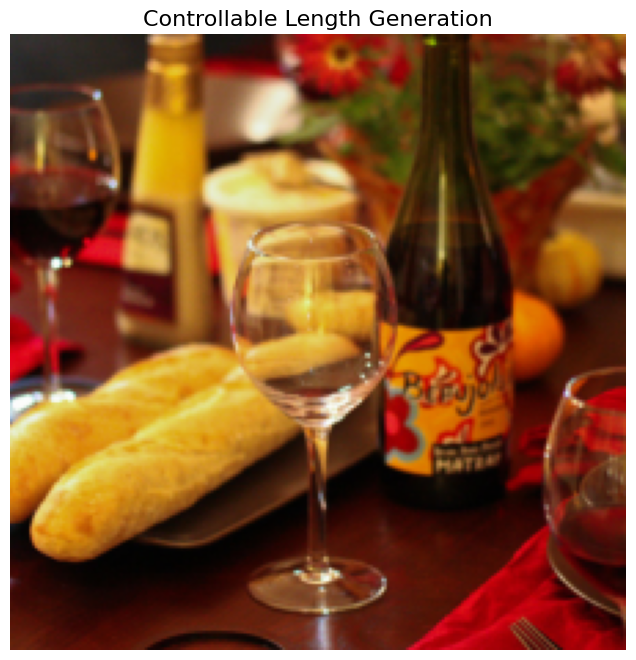

SHORT SIGNAL (< 8 words):
    a

MEDIUM SIGNAL (8-12 words):
   a man is eating a doughnut

LONG SIGNAL (13+ words):
   a man is eating a hot dog in a bun



In [17]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

image_tensor, original_caption_tensor, _, _ = val_dataset[5]
image_tensor = image_tensor.to(device)

short_signal = torch.tensor([vocab.SHORT_idx]).to(device)
medium_signal = torch.tensor([vocab.MEDIUM_idx]).to(device)
long_signal = torch.tensor([vocab.LONG_idx]).to(device)

with torch.no_grad():
    short_cap, _ = generate_caption(model, image_tensor, vocab, max_len=50, control_signal=short_signal)
    medium_cap, _ = generate_caption(model, image_tensor, vocab, max_len=50, control_signal=medium_signal)
    long_cap, _ = generate_caption(model, image_tensor, vocab, max_len=50, control_signal=long_signal)

img_display = image_tensor.cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(img_display)
plt.axis('off')
plt.title("Controllable Length Generation", fontsize=16)
plt.show()

print(f"SHORT SIGNAL (< 8 words):")
print(f"    {short_cap}\n")

print(f"MEDIUM SIGNAL (8-12 words):")
print(f"   {medium_cap}\n")

print(f"LONG SIGNAL (13+ words):")
print(f"   {long_cap}\n")

---
**Remember to save and upload your `.ipynb` file to Canvas before the deadline!**